# Hazard forecasts and impacts forecasts

In this tutorial, we showcase CLIMADA functionality to handle forecast data using the classes `HazardForecast` and `ImpactForecast`.


## Table of Contents

1. [Reading & processing forecast data](#1-reading--processing-forecast-data)
   - 1.1 [Using MeteoSwiss Open Government Data weather forecasts](#11-using-meteoswiss-open-government-data-weather-forecasts)
   - 1.2 [Using CLIMADA API demo data](#12-using-climada-api-demo-data)
2. [Impact Forecast calculation](#2-impact-forecast-calculation)
3. [Products based on ImpactForecast](#3-products-based-on-impactforecast)
   - 3.1 [Per ensemble member, per lead time](#31-per-ensemble-member-per-lead-time)
   - 3.2 [All ensemble members, per lead time](#32-all-ensemble-members-per-lead-time)
   - 3.3 [All ensemble members and lead times](#33-all-ensemble-members-and-lead-times)

In [52]:
# import necessary packages
import xarray as xr
import numpy as np
import pandas as pd

# import numbers
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature

admin1 = cfeature.NaturalEarthFeature(
    category="cultural", name="admin_1_states_provinces_lines", scale="10m"
)
lakes = cfeature.LAKES.with_scale("10m")
borders = cfeature.BORDERS.with_scale("10m")

from climada.entity import ImpactFunc, ImpactFuncSet
from climada.entity.exposures.litpop import LitPop
from climada.engine import ImpactCalc, ImpactForecast

from climada.hazard.forecast import HazardForecast

from climada.util.config import CONFIG
from climada.util.api_client import Client, DatasetInfo


## 1. Reading & processing forecast data


### 1.1 Using MeteoSwiss Open Government Data weather forecasts

This example retrieves the latest OGD forecast data from MeteoSwiss.
You can also skip this step and go to section 1.2 for using stored demo data from the CLIMADA API.

Requires the package `meteodata-lab`, available via `pip`.

You can find out all about data openly published here (info and notebooks on how to retrieve):

Check out:
* https://github.com/MeteoSwiss/meteodata-lab and
* https://github.com/MeteoSwiss/opendata-nwp-demos/blob/main/01_retrieve_process_precip.ipynb
* https://www.meteoschweiz.admin.ch/service-und-publikationen/service/open-data.html



In [53]:
# optional packages for this section only
from meteodatalab import ogd_api
from meteodatalab.operators import time_operators as time_ops
from earthkit.data import config

config.set("cache-policy", "temporary")

In [54]:
# Define target lead times for ICON-CH2-EPS: up 5d, here +0h, to +12h
lead_times = [f"P0DT{i}H" for i in np.arange(0, 13)]
model = "ogd-forecasting-icon-ch2"
nwp_vars = ["TOT_PREC", "VMAX_10M"]  # precip. and wind; temperature: "T_2M"
reftime = "latest"  # also try: 'latest'

In [55]:
dict_ens_data = {}
for var in nwp_vars:
    req = ogd_api.Request(
        collection=model,
        variable=var,
        ref_time=reftime,
        perturbed=True,  # ensembles
        lead_time=lead_times,
    )
    dict_ens_data[var] = ogd_api.get_from_ogd(req)

dict_ens_data["TOT_PREC"] = time_ops.delta(
    dict_ens_data["TOT_PREC"], np.timedelta64(1, "h")
)

In [56]:
ds_icon_latest = xr.Dataset(dict_ens_data)
init_time_str = np.datetime_as_string(ds_icon_latest.ref_time.values[0], unit="h")

After loading the data as a netcdf file, we read it into a `HazardForecast` object (see next subsection for more details on the structuer of this class).

In [57]:
haz_fc_icon_latest = HazardForecast.from_xarray_raster(
    ds_icon_latest,
    hazard_type="PR",
    intensity_unit="mm/h",
    coordinate_vars={
        "longitude": "lon",
        "latitude": "lat",
        "lead_time": "lead_time",
        "member": "eps",
    },
    intensity="TOT_PREC",
)

2025-12-17 15:05:35,790 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates. Hazard.event_name will be empty strings
2025-12-17 15:05:35,795 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates or ordinals. Hazard.date will be ones only


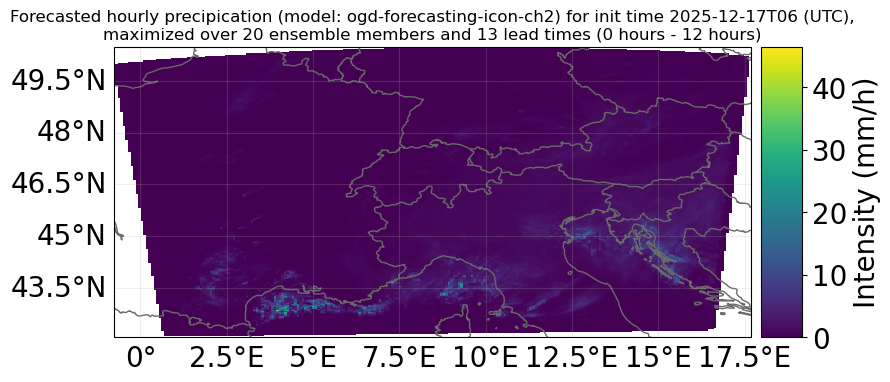

In [58]:
# plot whether there is precipitation in the forecast
ax = haz_fc_icon_latest.plot_intensity(event=0)
lead_times = np.unique(haz_fc_icon_latest.lead_time).astype("timedelta64[h]")
ax.set_title(
    f"Forecasted hourly precipication (model: {model}) for init time {init_time_str} (UTC),\n"
    f"maximized over {len(np.unique(haz_fc_icon_latest.member))} ensemble members and {len(lead_times)} lead times ({lead_times[0]} - {lead_times[-1]})"
);

### 1.2 Using CLIMADA API demo data

As an example, we load existing forecast data for an event including heavy precipitation and flooding on June 21, 2024 in in Misox, Switzerland.

After loading the data as a netcdf file, we read it into a `HazardForecast` object.

In [59]:
# get the demo forecast netCDF file fcst_icon_seamless_2024-06-18_12_00.nc via CLIMADA API
client = Client()
ds_info_icon_fcst = client.get_dataset_info_by_uuid(
    "60229fa0-4d5d-4f39-876c-b4344579d6eb"
)
_, path_to_forecast_nc = client.download_dataset(ds_info_icon_fcst)

Load into `HazardForecast` file from NetCDF on disk.

In [60]:
hazard_forecast = HazardForecast.from_xarray_raster(
    path_to_forecast_nc[0],
    hazard_type="PR",
    intensity_unit="mm/h",
    coordinate_vars={
        "longitude": "x",
        "latitude": "y",
        "lead_time": "lead_time",
        "member": "realization",
    },
    intensity="precipitation_amount_1hsum",
    crs="EPSG:2056",
)
# transform to EPSG:4326
hazard_forecast.centroids.gdf = hazard_forecast.centroids.gdf.to_crs(epsg=4326)

/Users/ldr.riedel/coding/climada_python/climada/hazard/forecast.py:372: FutureWarning: In a future version, xarray will not decode the variable 'lead_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  # Open dataset if needed


2025-12-17 15:06:32,477 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates. Hazard.event_name will be empty strings
2025-12-17 15:06:32,482 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates or ordinals. Hazard.date will be ones only


`HazardForecast` objects include forecasts produced at a specific initializatio (or reference) time, but for several several lead times and several forecast ensemble members. For this, it includes the two array-like attributes:
- `member` to indicate the forecast ensemble member, and
- `lead_time` to indicate the lead time of the data,

both of which can be used to select specific forecasts.

In [21]:
# Have a look at the Structure of HazardForecast
?HazardForecast

Init signature:
HazardForecast(
    lead_time: numpy.ndarray | None = None,
    member: numpy.ndarray | None = None,
    **hazard_kwargs,
)
Docstring:      A hazard object with forecast information
Init docstring:
Initialize a HazardForecast object.

Parameters
----------
lead_time : np.ndarray of np.timedelta64 or None, optional
    Forecast lead times. Default is empty array.
member : np.ndarray or None, optional
    Ensemble member identifiers as integers. Default is empty array.
**hazard_kwargs
    keyword arguments to pass to :py:class:`~climada.hazard.base.Hazard` See
    py:meth`~climada.hazard.base.Hazard.__init__` for details.
File:           ~/coding/climada_python/climada/hazard/forecast.py
Type:           type
Subclasses:     

In [61]:
pd.DataFrame.from_records(
    {
        "member": hazard_forecast.member,
        "lead_time": hazard_forecast.lead_time,
        "event_name": hazard_forecast.event_name,
        "event_id": hazard_forecast.event_id,
    }
).head(25)

,event_id,event_name,lead_time,member
0,1,lt_0h_m_0,0 days 00:00:00,0
1,2,lt_0h_m_1,0 days 00:00:00,1
2,3,lt_0h_m_2,0 days 00:00:00,2
3,4,lt_0h_m_3,0 days 00:00:00,3
4,5,lt_0h_m_4,0 days 00:00:00,4
5,6,lt_0h_m_5,0 days 00:00:00,5
6,7,lt_0h_m_6,0 days 00:00:00,6
7,8,lt_0h_m_7,0 days 00:00:00,7
8,9,lt_0h_m_8,0 days 00:00:00,8
9,10,lt_0h_m_9,0 days 00:00:00,9


Text(0.5, 1.0, 'Precipation Forecast for member 10 and lead time 78 hours')

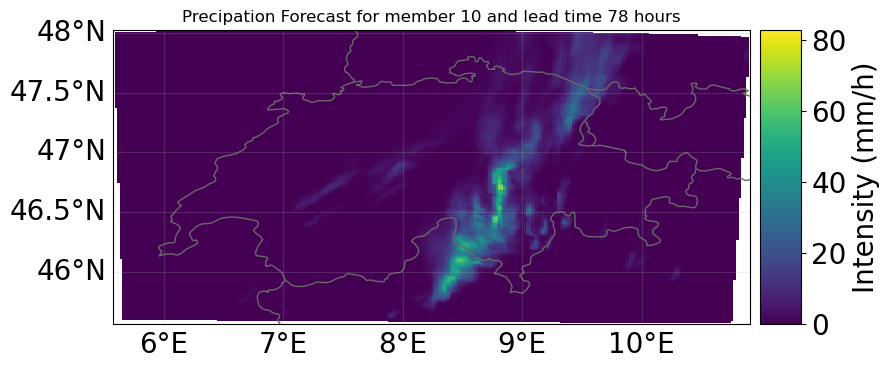

In [62]:
# select hazard forecast for a specific member and a specific lead time
test_member = 10
test_lead_time = np.timedelta64(78, "h")

# plot
ax = hazard_forecast.select(
    member=test_member,
    lead_time=test_lead_time,
).plot_intensity(0)
ax.set_title(
    f"Precipation Forecast for member {test_member} and lead time {test_lead_time.astype('timedelta64[h]')}"
)

The two forecast attributes `member` and `lead_time` can be used to generate (centroid-wise) statistics by means of methods like, e.g.,
- `.quantile(q=.3, event_name="30th Q")` to compute the 0.3-quantile of the hazard intensity over the members, for each lead time and centroid

In [12]:
# TODO: no other stats implemented for HazardForecast?
# - `.max()` to compute the maximum hazard intensity over the lead times, for each member and centroid,
# - `.mean()` to compute the mean of the hazard intensity over all lead times and members, for each centroid.

Text(0.5, 1.0, 'Mean of members for Precipitation Forecast at lead time 78 hours')

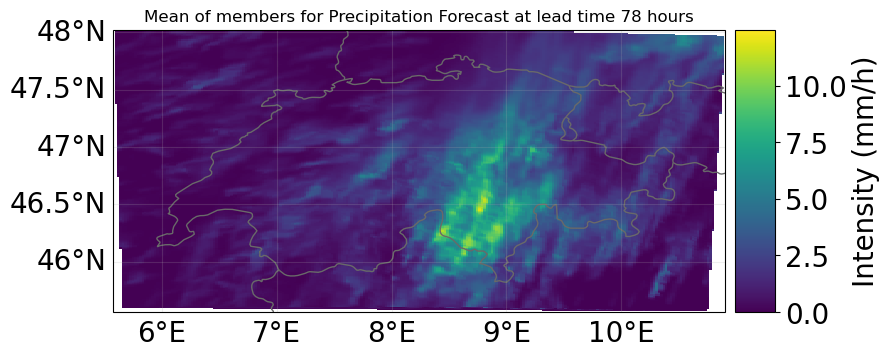

In [63]:
# plot median over member dimension for given a lead time
# TODO: does not work.
haz_med = hazard_forecast.mean(dim="member")
ax = haz_med.select(lead_time=test_lead_time).plot_intensity(0)

ax.set_title(
    f"Mean of members for Precipitation Forecast at lead time {test_lead_time}"
)

While most meteorological data come as `netCDF (.nc)`, `HazardForecast` objects can be 
written to and read from `HDF5 (.h5)` files using the methods:
* `write_hdf5()`
* `from_hdf5()`

In [64]:
from tempfile import TemporaryDirectory

# write hazard forecast object to HDF5 file
with TemporaryDirectory() as tmpdir:

    hazard_forecast.write_hdf5(Path(tmpdir) / "demo_hazard_forecast.h5")

    # read hazard forecast from HDF5 file
    hazard_forecast_read = HazardForecast.from_hdf5(
        Path(tmpdir) / "demo_hazard_forecast.h5"
    )

2025-12-17 15:08:48,467 - climada.hazard.io - INFO - Writing /var/folders/fj/w4lbl0pd7l1gcvt664mkfnh00000gq/T/tmpnk4k1ed5/demo_hazard_forecast.h5
2025-12-17 15:08:48,789 - climada.hazard.centroids.centr - INFO - Writing /var/folders/fj/w4lbl0pd7l1gcvt664mkfnh00000gq/T/tmpnk4k1ed5/demo_hazard_forecast.h5
2025-12-17 15:08:48,841 - climada.hazard.io - INFO - Reading /var/folders/fj/w4lbl0pd7l1gcvt664mkfnh00000gq/T/tmpnk4k1ed5/demo_hazard_forecast.h5


## 2. Impact Forecast calculation

`HazardForecast` objects can be handed in to the standard `CLIMADA ImpactCalc` engine to produce `ImpactForecast` objects, consisting of one impact forecast per hazard forecast.


We exemplify this below by loading a population exposure layer for Switzerland and Liechtenstein, and by defining a step impact function. This impact function results in impacts describing how much population (how many people) are exposed to a precipitation of more than 50mm/h for the severe precipitation event in Misox loaded above.

In [40]:
# Check out the structure of the ImpactForecast
?ImpactForecast

Init signature:
ImpactForecast(
    *,
    lead_time: numpy.ndarray | None,
    member: numpy.ndarray | None,
    **impact_kwargs,
)
Docstring:      An impact object with forecast information
Init docstring:
Initialize the impact forecast.

Parameters
----------
lead_time : np.ndarray, optional
    The lead time associated with each event entry, given as timedelta64 type
member : np.ndarray, optional
    The ensemble member associated with each event entry, given as integers
impact_kwargs
    Keyword-arguments passed to ~:py:class`climada.engine.impact.Impact`.
File:           ~/coding/climada_python/climada/engine/impact_forecast.py
Type:           type
Subclasses:     

2025-12-17 15:09:14,367 - climada.entity.exposures.litpop.litpop - INFO - 
 LitPop: Init Exposure for country: CHE (756)...

2025-12-17 15:09:14,961 - climada.entity.exposures.litpop.litpop - INFO - 
 LitPop: Init Exposure for country: LIE (438)...

2025-12-17 15:09:15,057 - climada.entity.exposures.base - INFO - Hazard type not set in impf_
2025-12-17 15:09:15,057 - climada.entity.exposures.base - INFO - category_id not set.
2025-12-17 15:09:15,057 - climada.entity.exposures.base - INFO - cover not set.
2025-12-17 15:09:15,058 - climada.entity.exposures.base - INFO - deductible not set.
2025-12-17 15:09:15,058 - climada.entity.exposures.base - INFO - centr_ not set.
2025-12-17 15:09:15,098 - climada.entity.exposures.base - INFO - Matching 70525 exposures with 27000 centroids.
2025-12-17 15:09:15,167 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 100 degree


<Axes: title={'center': 'PR 1: Severe Precipitation Step Function'}, xlabel='Intensity (mm/h)', ylabel='Impact (%)'>

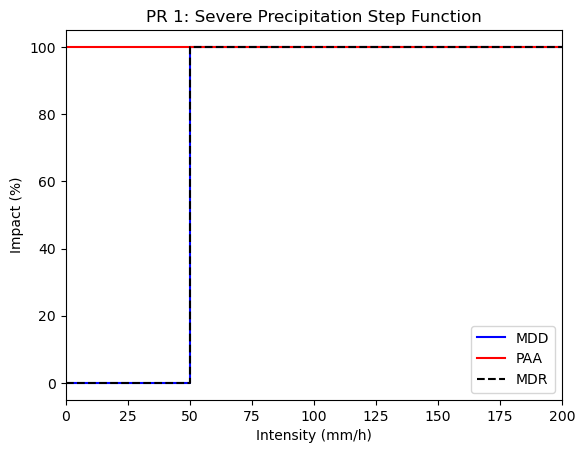

In [65]:
# Read exposure for population
exp_che = LitPop.from_population(countries=["CHE", "LIE"], res_arcsec=30)
# Assign centroids because hazard not on regular grid
exp_che.assign_centroids(hazard_forecast, threshold=100)

# define impact functions
threshold_for_affected = 50
imp_fun_precip = ImpactFunc.from_step_impf(
    (0, threshold_for_affected, 200),
    haz_type=f"PR",
    impf_id=1,
    intensity_unit="mm/h",
    name="Severe Precipitation Step Function",
)
impf_set = ImpactFuncSet([imp_fun_precip])
impf_set.plot()

In [66]:
# calculate impact
impact_forecast = ImpactCalc(exp_che, impf_set, hazard_forecast).impact(
    assign_centroids=False,  # assign_centroid=False because we do not want to reassign centroids
)  # impact matrix is saved by default

2025-12-17 15:09:53,513 - climada.entity.exposures.base - INFO - No specific impact function column found for hazard PR. Using the anonymous 'impf_' column.
2025-12-17 15:09:53,521 - climada.engine.impact_calc - INFO - Calculating impact for 208182 assets (>0) and 2415 events.
2025-12-17 15:09:53,906 - climada.engine.impact_calc - WARNING - eai_exp and aai_agg are undefined with forecasts. Setting them to NaN arrays.
2025-12-17 15:09:53,930 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold
2025-12-17 15:09:53,932 - climada.engine.impact_forecast - WARNING - at_event gives the total impact for one specific combination of member and lead_time.


In [67]:
pd.DataFrame.from_records(
    {
        "member": impact_forecast.member,
        "lead_time": impact_forecast.lead_time,
        "event_name": impact_forecast.event_name,
        "event_id": impact_forecast.event_id,
    }
).head(25)

,event_id,event_name,lead_time,member
0,1,lt_0h_m_0,0 days 00:00:00,0
1,2,lt_0h_m_1,0 days 00:00:00,1
2,3,lt_0h_m_2,0 days 00:00:00,2
3,4,lt_0h_m_3,0 days 00:00:00,3
4,5,lt_0h_m_4,0 days 00:00:00,4
5,6,lt_0h_m_5,0 days 00:00:00,5
6,7,lt_0h_m_6,0 days 00:00:00,6
7,8,lt_0h_m_7,0 days 00:00:00,7
8,9,lt_0h_m_8,0 days 00:00:00,8
9,10,lt_0h_m_9,0 days 00:00:00,9


## 3. Products based on ImpactForecast

We can now analyse the impact forecasts by selecting specific ensemble member or lead times (or other impact attributes), or by computing statistics (min, max, quantile, mean) over the forecast dimensions `member` and `lead_time`.

For the specific case of Misox, we will zoom in to the canton of Ticino which was most heavily affected.

### 3.1 Per ensemble member, per lead time

2025-12-17 15:10:26,589 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the frequencies.


Text(0.5, 1.0, 'Affected people from precip>50mm/h\nfor member 10 and lead time 78 hours')

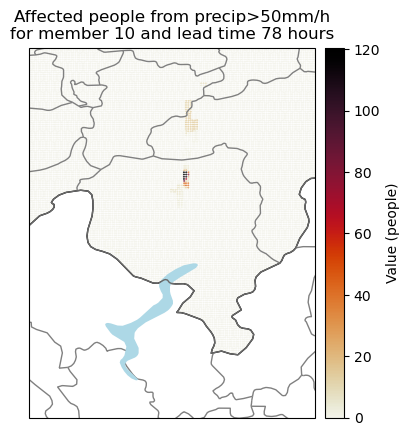

In [68]:
# select for a specific member and a specific lead time and plot Ticino extent

impact_forecast_1m_1lt = impact_forecast.select(
    member=test_member,
    lead_time=test_lead_time,
)
extent_ticino = [8.2, 9.3, 45.58, 47]

fig = plt.figure(figsize=(6, 4))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(borders, linewidth=1)
ax.add_feature(admin1, edgecolor="gray", linewidth=1.0, facecolor="none")
ax.add_feature(lakes, facecolor="lightblue")

# plot impact forecast
impact_forecast_1m_1lt.plot_hexbin_impact_exposure(
    event_id=impact_forecast_1m_1lt.event_id, pop_name=False, axis=ax
)
ax.set_extent(extent_ticino)
ax.set_title(
    f"Affected people from precip>{threshold_for_affected}mm/h\nfor member {test_member} and lead time {test_lead_time.astype('timedelta64[h]')}"
)

### 3.2 All ensemble members, per lead time

In [44]:
# TODO easy function to create per member a map of maximum impact over all leatimes
# sth along this line:
# max_impact_per_member = impact_forecast.max(dim="lead_time")

2025-12-17 15:10:54,383 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the frequencies.


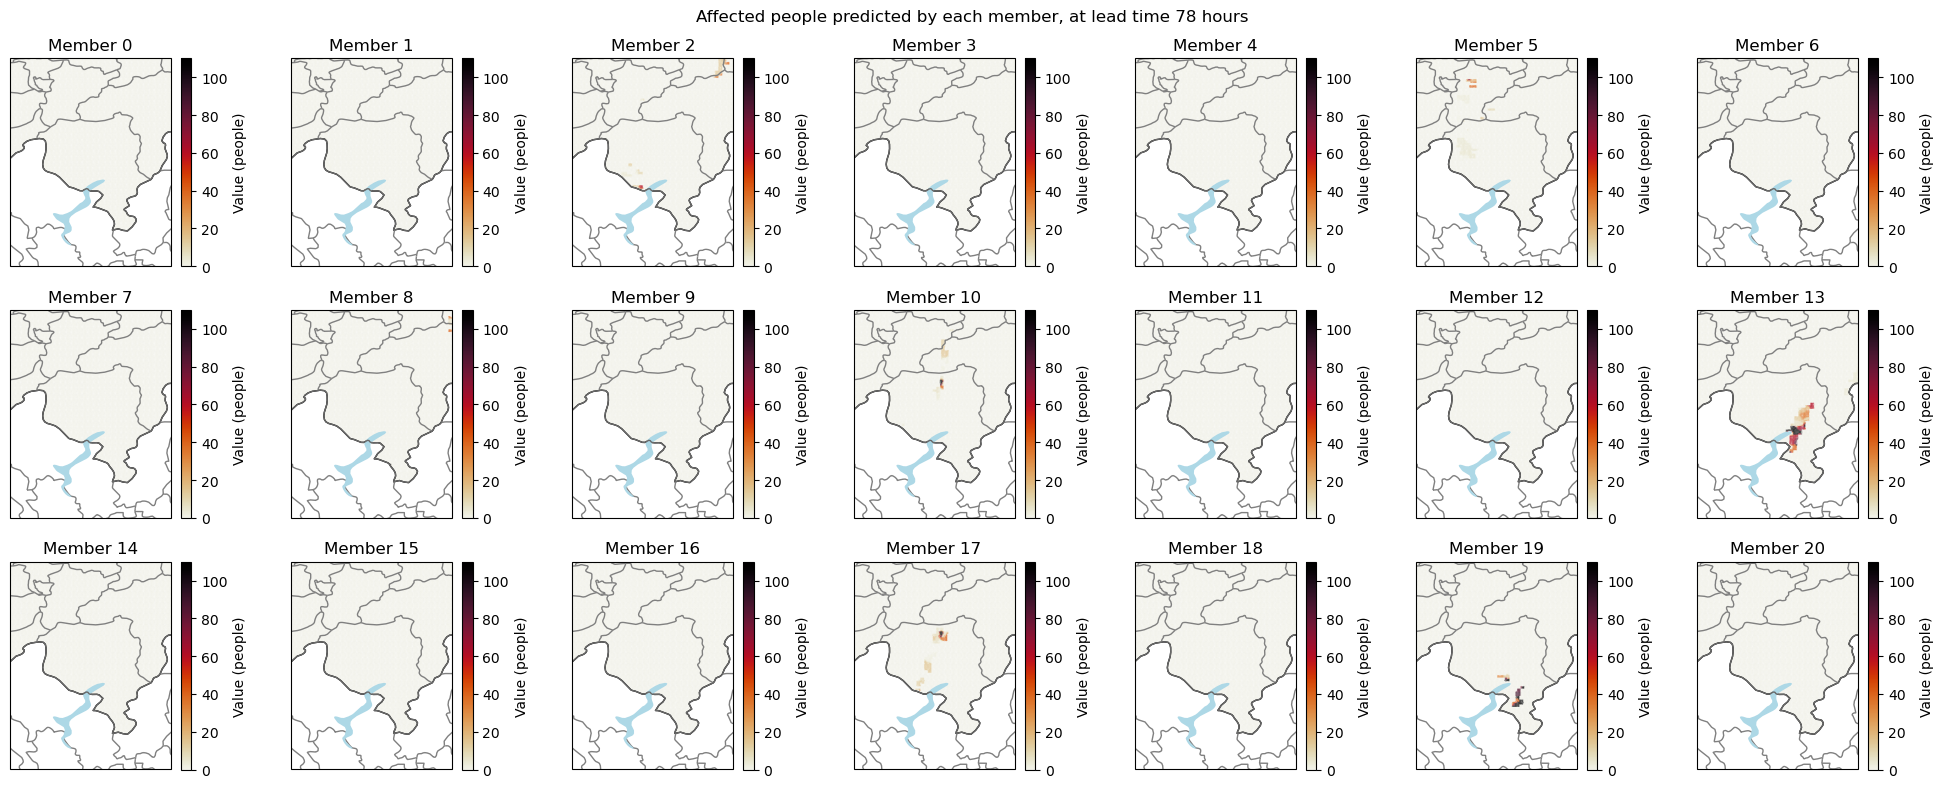

In [ ]:
imp_fct_all_mem_1lt = impact_forecast.select(lead_time=test_lead_time)

fig, ax = plt.subplots(
    3, 7, figsize=(20, 8), subplot_kw={"projection": ccrs.PlateCarree()}
)
fig.suptitle(f"Affected people predicted by each member, at lead time {test_lead_time}")
ax = ax.flatten()
for j, member in enumerate(imp_fct_all_mem_1lt.member):
    ax[j].add_feature(borders, linewidth=1)
    ax[j].add_feature(admin1, edgecolor="gray", linewidth=1.0, facecolor="none")
    ax[j].add_feature(lakes, facecolor="lightblue")

    # plot impact forecast
    imp_fct_all_mem_1lt.plot_hexbin_impact_exposure(
        event_id=imp_fct_all_mem_1lt.event_id[j],
        pop_name=False,
        axis=ax[j],
        vmin=0,
        vmax=110,
    )
    ax[j].set_extent(extent_ticino)
    ax[j].set_title(f"Member {j}")

Next, we can analyse the evolution of predicted number of affected people over Switzerland (member distribution shown as a histogram) with increasing forecast lead time.

### 3.3 All ensemble members and lead times

2025-12-17 13:05:25,052 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the frequencies.
2025-12-17 13:05:25,293 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the frequencies.
2025-12-17 13:05:25,308 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the frequencies.
2025-12-17 13:05:25,323 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the frequencies.
2025-12-17 13:05:25,340 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the frequencies.
2025-12-17 13:05:25,398 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the

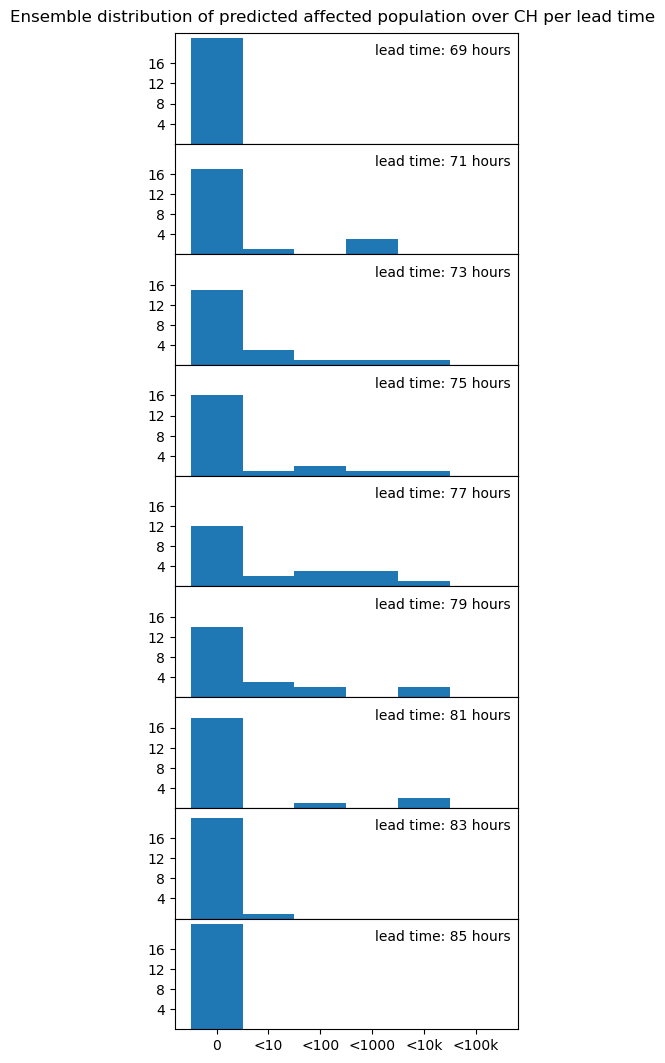

In [46]:
lead_time_window = np.timedelta64(1, "h") * np.arange(69, 87, 2)
n_lead_times = len(lead_time_window)

fig, ax = plt.subplots(
    nrows=n_lead_times,
    ncols=1,
    figsize=(4, 1.2 * n_lead_times),
    sharex=True,
    sharey=True,
)
ax = ax.flatten()
log_histogram_bins = np.arange(7)

for j, lead_time in enumerate(lead_time_window):
    imp_fct_all_mem_1lt = impact_forecast.select(lead_time=lead_time)
    imp_per_member = imp_fct_all_mem_1lt.imp_mat.sum(axis=1)
    ax[j].hist(np.log10(imp_per_member + 1), bins=log_histogram_bins, alpha=1)
    ax[j].set_yticks([4, 8, 12, 16])
    ax[j].text(
        0.98,
        0.90,
        f"lead time: {lead_time.astype('timedelta64[h]')}",
        ha="right",
        va="top",
        transform=ax[j].transAxes,
    )

ax[-1].set_xlabel("")

bin_centers = 0.5 * (log_histogram_bins[:-1] + log_histogram_bins[1:])
ax[-1].set_xticks(bin_centers)
ax[-1].set_xticklabels(["0", "<10", "<100", "<1000", "<10k", "<100k"])

plt.suptitle(
    "Ensemble distribution of predicted affected population over CH per lead time"
)
plt.tight_layout()
plt.subplots_adjust(hspace=0)

Attributes of an `ImpactForecast` object that do not make sense if impacts correspond to different ensemble members and lead times (instead of impacts of different events in a probabilistic event set as usual in `Impact` objects) are filled with NaNs.

In [47]:
print("average annual imact: ", impact_forecast.aai_agg)
print("average annual impact per centroid: ", impact_forecast.eai_exp)
try:
    impact_forecast.calc_freq_curve()
except NotImplementedError as e:
    print(e)

average annual imact:  nan
average annual impact per centroid:  [nan nan nan ... nan nan nan]
2025-12-17 13:05:26,036 - climada.engine.impact_forecast - ERROR - calc_freq_curve is not defined for ImpactForecast
calc_freq_curve is not defined for ImpactForecast


`ImpactForecast` objects can be written to and read from hdf5 files:

In [49]:
# write hazard forecast object to h5 file
with TemporaryDirectory() as tmpdir:
    impact_forecast.write_hdf5(Path(tmpdir) / "demo_impact_forecast.h5")

    # read hazard forecast from h5 file
    imp_fct = ImpactForecast.from_hdf5(Path(tmpdir) / "demo_impact_forecast.h5")

TypeError: iteration over a 0-d array